# Investigating the measurement I made in 13.05.2024

In [278]:
from scipy import signal
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.signal import butter, sosfiltfilt
from matplotlib.ticker import FuncFormatter

%matplotlib widget

## Data loading and setting definition

In [279]:
raw_dataset = np.load(r'../Data/Subject_raw_dataset.npy')

In [280]:
fs = 2e9

### Plotting enveloped US response

(204, 50000)
(50000,)
[-12 -16  -9 ... -48 -48 -48]
[0.0000000e+00 3.8500000e-04 7.7000000e-04 ... 1.9248845e+01 1.9249230e+01
 1.9249615e+01]


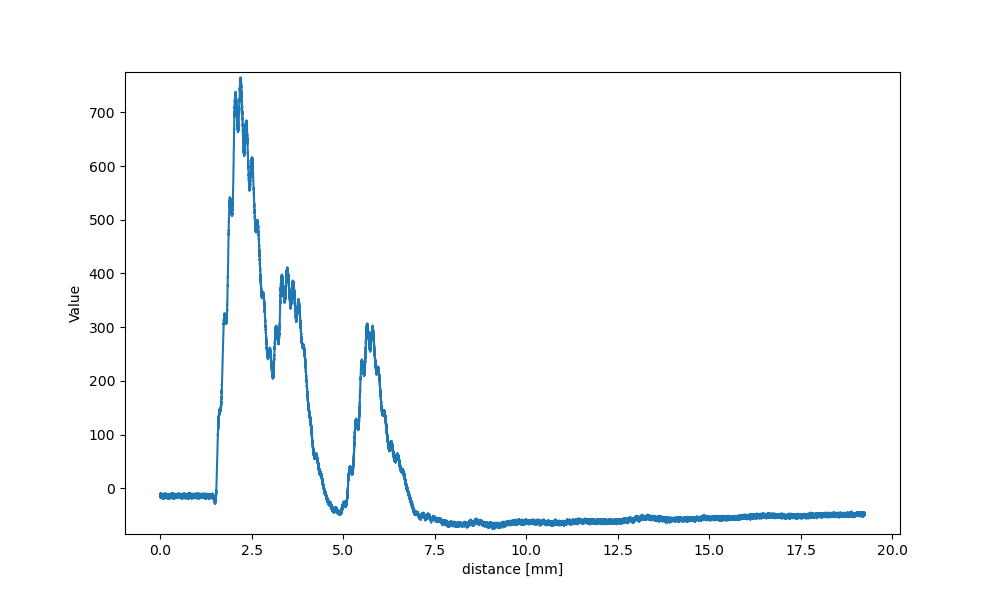

In [281]:
print(raw_dataset.shape)
print(raw_dataset[0].shape)

raw_data = raw_dataset[0]
print(raw_data)
distance =  np.arange(len(raw_data))* 1/fs * 1540 / 2 * 1000
print(distance)

plt.figure(figsize=(10, 6))
plt.plot(distance, raw_data)
plt.ylim(np.min(raw_data)-10, np.max(raw_data)+10)
plt.xlabel("distance [mm]")
plt.ylabel("Value")
plt.show()

### Butterworth filters with numerically stable sos type

In [282]:
def butter_bandpass(lowcut, highcut, fs, order, output):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    sos = butter(order, [low, high], btype='band', output='sos')
    return sos
def butter_bandpass_filtfilt(data, lowcut, highcut, fs, order):
    sos = butter_bandpass(lowcut, highcut, fs, order=order, output='sos')
    y = sosfiltfilt(sos, data)
    return y

def butter_lowpass(cutoff, fs, order):
    normal_cutoff = cutoff / (0.5*fs)
    sos = butter(order, normal_cutoff,btype='low', output='sos')
    return sos
def butter_lowpass_filtfilt(data, cutoff, fs, order):
    sos = butter_lowpass(cutoff, fs, order=order)
    y = sosfiltfilt(sos, data)
    return y

def butter_highpass(cutoff, fs, order):
    normal_cutoff = cutoff / (0.5*fs)
    sos = butter(order, normal_cutoff,btype='high', output='sos')
    return sos
def butter_highpass_filtfilt(data, cutoff, fs, order):
    sos = butter_highpass(cutoff, fs, order=order)
    y = sosfiltfilt(sos, data)
    return y

# Preprocessing

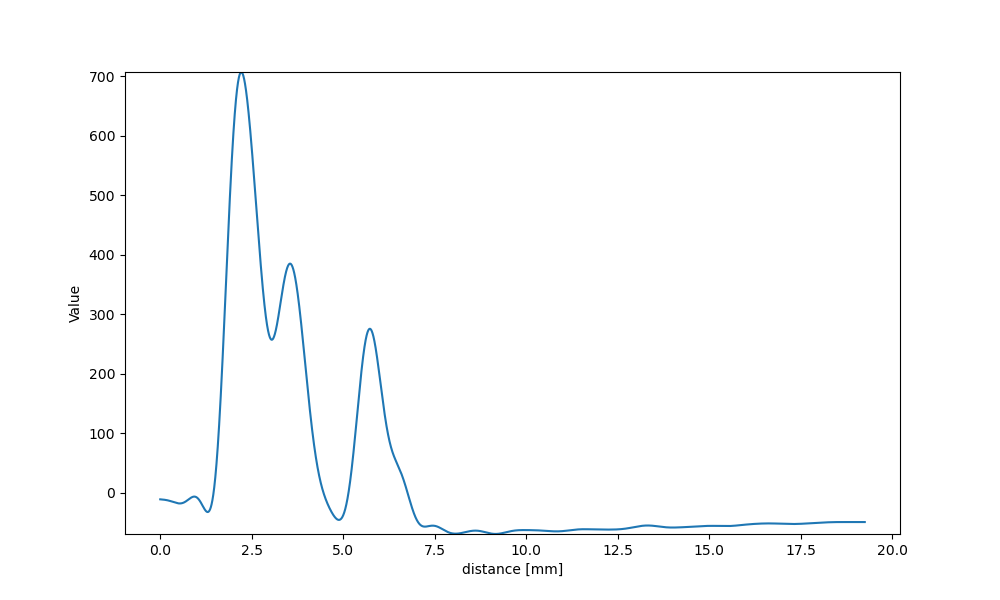

In [283]:
raw_dataset_filt= butter_lowpass_filtfilt(raw_dataset, 10e5, fs=fs, order=6)
plt.figure(figsize=(10, 6))
plt.plot(distance, raw_dataset_filt[0])
plt.ylim(np.min(raw_dataset_filt[0])-0.1, np.max(raw_dataset_filt[0])+0.1)
plt.xlabel("distance [mm]")
plt.ylabel("Value")
plt.show()

In [284]:
idx_3mm = int(3*fs*2//(1540*1000))
idx_7mm = int(7*fs*2//(1540*1000))

data_interest = raw_dataset_filt[:,idx_3mm:idx_7mm]
distance_interest = distance[idx_3mm:idx_7mm]

print(data_interest.shape)
print(data_interest.shape)

(204, 10389)
(204, 10389)


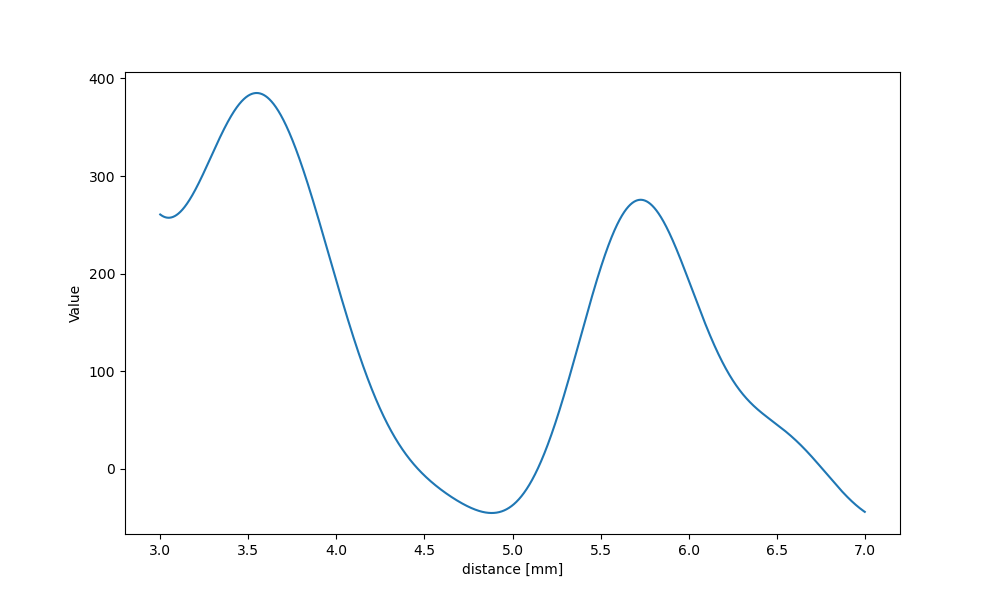

In [285]:
plt.figure(figsize=(10, 6))
plt.plot(distance_interest, data_interest[0])
plt.xlabel("distance [mm]")
plt.ylabel("Value")
plt.show()

In [286]:
def sliding_window_covariance(x, y, window_size):
    N = len(x)
    cov_result = np.zeros(N)

    for i in range(window_size//2, N - window_size//2):
        x_window = x[i-window_size//2:i+window_size//2+1]
        y_window = y[i-window_size//2:i+window_size//2+1]

        cov_result[i] = np.sum(x_window*y_window)/window_size

    cov_result = (cov_result - np.min(cov_result))/(np.max(cov_result) - np.min(cov_result)) # normalize
    cov_result[cov_result < 0.01] = 0

    return cov_result

# Wall detection

In [287]:
R = data_interest
R = (R - np.min(R))/(np.max(R) - np.min(R))
print(len(R))

204


In [288]:
Max_shift = []

W1 = []
W2 = []
all_peaks = []
idx_dist_1mm = int(1*fs*2//(1540*1000))
W = int(0.5*fs*2//(1540*1000))
tester_num = 8

for i in range(tester_num-1):
    swc = sliding_window_covariance(R[i], R[i+1], W)
    peaks, _ = signal.find_peaks(swc, distance=idx_dist_1mm)
    all_peaks.append(peaks)  

max_len = max(len(sublist) for sublist in all_peaks)
array_shape = (len(all_peaks), max_len)
result_array = np.full(array_shape, np.nan)
for i, sublist in enumerate(all_peaks):
    result_array[i, :len(sublist)] = sublist
all_peaks = result_array

print(all_peaks)

W = int(0.5*fs*2//(1540*1000))

for i in range(1,all_peaks.shape[0]):
    S = []
    for j in range(all_peaks.shape[1]):
        try:
            W0 = R[0][int(all_peaks[i,j]-W):int(all_peaks[i,j]+W)]
            Wm = R[i][int(all_peaks[i,j]-W):int(all_peaks[i,j]+W)]
            peaks_0, _ = signal.find_peaks(W0)
            peaks_m, _ = signal.find_peaks(Wm)
            if len(peaks_0) != 1 or len(peaks_m) != 1:
                S.append(np.nan)
            else:
                S.append(peaks_m[0]-peaks_0[0])
                Max_shift.append(peaks_m[0]-peaks_0[0])
        except:
            S.append(np.nan)
    print(S)
    correct_pair_corr = []
    for j in range(len(S)-1):
        if np.isnan(S[j]) or np.isnan(S[j+1]):
            correct_pair_corr.append(np.inf)
        else:
            correct_pair_corr.append(S[j]*S[j+1])
    if len(correct_pair_corr) == 0:
        W1.append(np.nan)
        W2.append(np.nan)
    else:
        best_idx = np.argmin(correct_pair_corr)
        print(correct_pair_corr)
        print(correct_pair_corr[best_idx])
        print(best_idx)
        print(all_peaks[i,best_idx])
        print(all_peaks[i,best_idx+1])
        W1.append(all_peaks[i,best_idx])
        W2.append(all_peaks[i,best_idx+1])
        #print(all_peaks[i,best_idx])
        #print(all_peaks[i,best_idx+1])
    print()

W1 = np.array(W1)
W2 = np.array(W2)

W1 = W1[~np.isnan(W1)]
W2 = W2[~np.isnan(W2)]

Wall1 = int(np.median(W1))
Wall2 = int(np.median(W2))

print(Wall1)
print(Wall2)

Max_shift = np.abs(Max_shift)
border = np.percentile(Max_shift, 2)
print(border)
print(border * 1/fs * 1540 / 2 * 1000)

[[1400. 7090.]
 [1432. 6994.]
 [1527. 6803.]
 [1619. 6704.]
 [1620. 6719.]
 [1605. 6745.]
 [1628. 6756.]]
[10, -43]
[-430]
-430
0
1432.0
6994.0

[65, -219]
[-14235]
-14235
0
1527.0
6803.0

[223, -448]
[-99904]
-99904
0
1619.0
6704.0

[263, -436]
[-114668]
-114668
0
1620.0
6719.0

[226, -415]
[-93790]
-93790
0
1605.0
6745.0

[230, -383]
[-88090]
-88090
0
1628.0
6756.0

1612
6750
17.259999999999998
0.006645099999999999


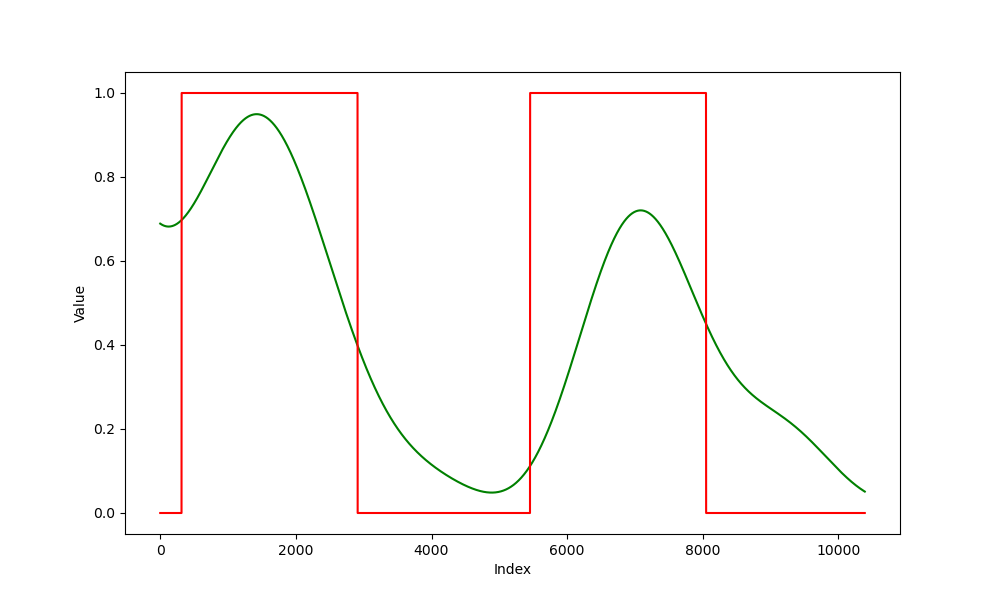

In [289]:
x = np.arange(len(R[0]))
condition1 = np.logical_and(x > Wall1 - W, x < Wall1 + W)
condition2 = np.logical_and(x > Wall2 - W, x < Wall2 + W)
combined_condition = np.logical_or(condition1, condition2)
windows = np.where(combined_condition, 1, 0)

plt.figure(figsize=(10, 6))
plt.plot(x, R[0] , color='g')
plt.plot(x, windows, color='r')
plt.ylabel("Value")
plt.xlabel("Index")
plt.show()

# Wall tracking

In [290]:
Proximal_wall = []
Distal_wall = []

for i in range(len(R)):
    W_p = R[i][Wall1-W:Wall1+W+1]
    W_d = R[i][Wall2-W:Wall2+W+1]
    peaks_p, _ = signal.find_peaks(W_p)
    peaks_d, _ = signal.find_peaks(W_d) 
    if len(peaks_p) != 1 or len(peaks_d) != 1:
        #Proximal_wall.append(np.nan)
        #Distal_wall.append(np.nan)
        Proximal_wall.append(Proximal_wall[i-1])
        Distal_wall.append(Distal_wall[i-1])
    else:
        Proximal_wall.append(distance_interest[Wall1+peaks_p[0]-W])
        Distal_wall.append(distance_interest[Wall2+peaks_d[0]-W])      



Proximal_wall = np.array(Proximal_wall)
Distal_wall = np.array(Distal_wall)
diameter = Distal_wall - Proximal_wall

# Evaluation

Correlation: -0.9598686926760711
The measurement was correct !!!!


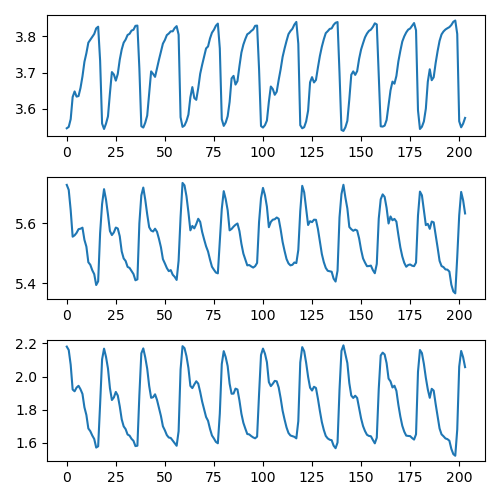

In [291]:
x_nonan = np.nan_to_num(Proximal_wall, nan=0.0)
y_nonan = np.nan_to_num(Distal_wall, nan=0.0)
correlation_coef = np.corrcoef(x_nonan, y_nonan)[0][1]
print(f"Correlation: {correlation_coef}")
if correlation_coef < 0:
    print("The measurement was correct !!!!")
else:
    print("The measurement was not correct !!!!")

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(5, 5))
ax1.plot(Proximal_wall)
ax2.plot(Distal_wall)
ax3.plot(diameter)

plt.tight_layout()

plt.show()

# Blood pressure estimation - exponential

204
Predicted SBP: 110.44459346492958 mmHg
Predicted DBP: 77.96121915341087 mmHg


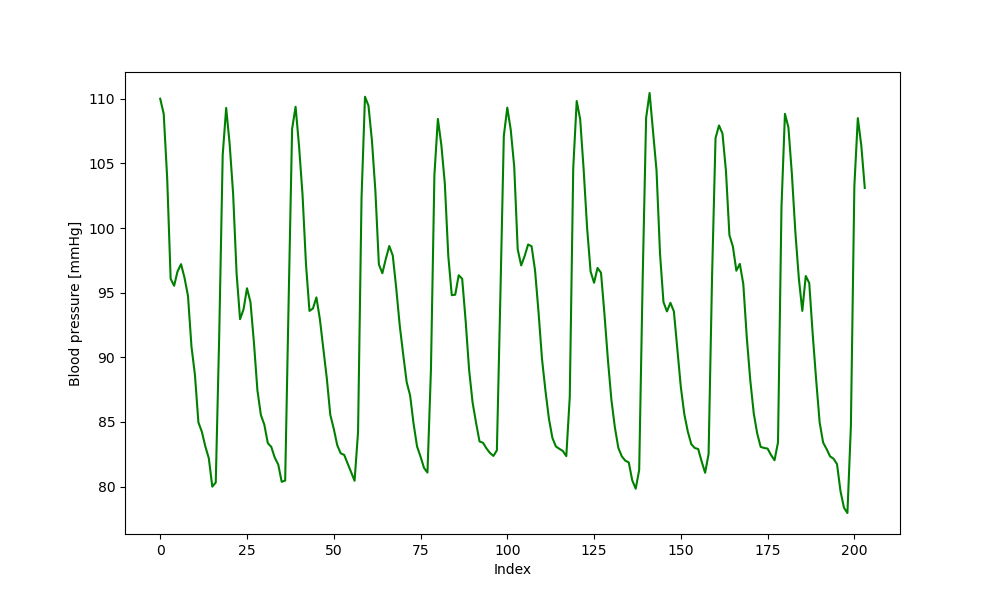

In [292]:
SBP = 110
DBP = 80
DS = np.max(diameter[0:40])
DD = np.min(diameter[0:40])

beta = np.log(SBP/DBP)/((DS-DD)/DD)
P = DBP*np.exp(beta*((diameter-DD)/DD))
print(len(P))

print(f"Predicted SBP: {np.max(P)} mmHg")
print(f"Predicted DBP: {np.min(P)} mmHg")

plt.figure(figsize=(10, 6))
plt.plot(P, color='g')
plt.xlabel("Index")
plt.ylabel("Blood pressure [mmHg]")
plt.show()